# Sample Characterization v2 (Tmag < 10)

Selects TIC stars with `Tmag < 10` from pre-fetched batch CSVs (no MAST queries).
Produces `processed/df_final.csv` (ID column only).

## Section 0 — Imports & config

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import lightkurve as lk

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

T              = 1024
STRIDE         = 1024
GAP_THRESHOLD  = 1        # days
NAN_THRESHOLD  = 0.10
CADENCE_DAYS   = 2 / 1440  # TESS 2-min in days

# Locate project root (contains CLAUDE.md)
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.parent != PROJECT_ROOT and not (PROJECT_ROOT / 'CLAUDE.md').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'CLAUDE.md').exists():
    raise FileNotFoundError('Cannot find project root (CLAUDE.md not found)')
PROCESSED = PROJECT_ROOT / 'processed'
print(f'Project root: {PROJECT_ROOT}')

Project root: c:\git_repo\Stellar-World-Model


## Section 1 — Load batch CSVs & apply cuts

In [3]:
batch_files = [
    PROCESSED / 'tic_candidates_batch_0_7.csv',
    PROCESSED / 'tic_candidates_batch_7_8.csv',
    PROCESSED / 'tic_candidates_batch_8_9.csv',
    PROCESSED / 'tic_candidates_batch_9_10.csv',
]

df_raw = pd.concat([pd.read_csv(f) for f in batch_files], ignore_index=True)
print(f'Combined rows: {len(df_raw):,}  |  columns: {list(df_raw.columns)}')

current = df_raw.copy()
print(f'\nInitial: {len(current):,} stars')

prev = len(current)
current = current[current['Tmag'] < 10].copy()
print(f'After Tmag < 10:    {len(current):,}  (dropped {prev - len(current):,})')

df_work  = current.reset_index(drop=True)   # retains all columns for plots
df_final = df_work[['ID']].copy()           # export: ID only
print(f'\ndf_final: {len(df_final):,} stars')

Combined rows: 594,689  |  columns: ['ID', 'Tmag', 'Teff', 'logg', 'plx', 'rad', 'mass']

Initial: 594,689 stars
After Tmag < 10:    594,649  (dropped 40)

df_final: 594,649 stars


## Section 2 — `plot_window` utility

Call `plot_window(star_idx, sector_idx=0, window_idx=0)` to inspect any star's light curve and window boundaries. Uses `df_work` (all columns retained).

In [4]:
def _regrid(time_arr: np.ndarray, flux_arr: np.ndarray):
    """Map observations onto a uniform 2-min grid; gaps become NaN."""
    t0      = time_arr[0]
    indices = np.round((time_arr - t0) / CADENCE_DAYS).astype(int)
    n_grid  = indices[-1] + 1
    t_grid  = t0 + np.arange(n_grid) * CADENCE_DAYS
    f_grid  = np.full(n_grid, np.nan)
    f_grid[indices] = flux_arr
    return t_grid, f_grid


def plot_window(star_idx: int, sector_idx: int = 0, window_idx: int = 0) -> None:
    row    = df_work.iloc[star_idx]
    tic_id = int(row['ID'])
    tmag   = row['Tmag']
    teff   = row['Teff'] if not pd.isna(row['Teff']) else float('nan')
    logg   = row['logg'] if not pd.isna(row['logg']) else float('nan')
    print(f'Star #{star_idx}: TIC {tic_id}  Tmag={tmag:.2f}  Teff={teff:.0f} K  logg={logg:.2f}')

    sr = lk.search_lightcurve(f'TIC {tic_id}', mission='TESS', author='SPOC', exptime=120)
    if len(sr) == 0:
        print('No SPOC 2-min data found.')
        return

    sectors    = list(sr.table['sequence_number'])
    sector_idx = min(sector_idx, len(sr) - 1)
    print(f'Available sectors ({len(sectors)}): {sectors}')
    print(f'Using sector index {sector_idx} → Sector {sectors[sector_idx]}')

    lc       = sr[sector_idx].download(quality_bitmask='none')
    raw_flux = lc['pdcsap_flux'].value.astype(float)
    raw_time = lc.time.value

    time_grid, flux_grid = _regrid(raw_time, raw_flux)
    n_grid  = len(flux_grid)
    n_nan   = int(np.isnan(flux_grid).sum())
    nan_pct = 100 * n_nan / n_grid

    print(f'\n── Sector {sectors[sector_idx]} NaN summary')
    print(f'  Downloaded cadences : {len(raw_flux)}')
    print(f'  Uniform grid points : {n_grid}')
    print(f'  NaN (gaps)          : {n_nan} / {n_grid}  ({nan_pct:.2f}%)')

    starts     = list(range(0, n_grid - T + 1, STRIDE))
    nan_counts = [int(np.isnan(flux_grid[s:s + T]).sum()) for s in starts]
    n_pass     = sum(1 for c in nan_counts if c / T < NAN_THRESHOLD)
    print(f'\n── Window breakdown (T={T}, stride={STRIDE})')
    print(f'  Total windows : {len(starts)}')
    print(f'  Pass NaN<10%  : {n_pass} / {len(starts)}')
    for wi, (s, nc) in enumerate(zip(starts, nan_counts)):
        marker = ' ✓' if nc / T < NAN_THRESHOLD else ' ✗'
        sel    = ' ← selected' if wi == min(window_idx, len(starts) - 1) else ''
        print(f'    [{wi:>3}] cadences [{s:>5}, {s+T:>5})  NaN={nc:>4}/{T}  ({100*nc/T:>5.1f}%){marker}{sel}')

    window_idx = min(window_idx, len(starts) - 1)
    s          = starts[window_idx]
    win_flux   = flux_grid[s:s + T]
    win_time   = time_grid[s:s + T]
    nan_count  = nan_counts[window_idx]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    axes[0].plot(time_grid, flux_grid, lw=0.5, color='steelblue', alpha=0.8)
    axes[0].axvspan(win_time[0], win_time[-1], color='orange', alpha=0.30, label=f'Window {window_idx}')
    axes[0].set_title(
        f'TIC {tic_id} — Sector {sectors[sector_idx]} (uniform grid)  |  '
        f'NaN: {n_nan}/{n_grid} ({nan_pct:.1f}%)', fontsize=12)
    axes[0].set_ylabel('PDCSAP Flux')
    axes[0].legend(fontsize=10)

    axes[1].plot(win_time, win_flux, lw=0.8, color='darkorange', marker='.', ms=2)
    axes[1].set_title(
        f'Window {window_idx}  |  grid pts [{s}, {s+T})  |  '
        f'NaN: {nan_count}/{T} ({100*nan_count/T:.1f}%)', fontsize=12)
    axes[1].set_xlabel('Time (BTJD)')
    axes[1].set_ylabel('PDCSAP Flux')

    plt.suptitle(
        f'TIC {tic_id}  Tmag={tmag:.2f}  Teff={teff:.0f} K  logg={logg:.2f}',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Star #2000: TIC 22901484  Tmag=5.52  Teff=3322 K  logg=nan
Available sectors (6): [np.int64(18), np.int64(42), np.int64(43), np.int64(44), np.int64(58), np.int64(85)]
Using sector index 5 → Sector 85

── Sector 85 NaN summary
  Downloaded cadences : 17904
  Uniform grid points : 18357
  NaN (gaps)          : 5127 / 18357  (27.93%)

── Window breakdown (T=1024, stride=1024)
  Total windows : 17
  Pass NaN<10%  : 9 / 17
    [  0] cadences [    0,  1024)  NaN= 616/1024  ( 60.2%) ✗ ← selected
    [  1] cadences [ 1024,  2048)  NaN= 470/1024  ( 45.9%) ✗
    [  2] cadences [ 2048,  3072)  NaN=   0/1024  (  0.0%) ✓
    [  3] cadences [ 3072,  4096)  NaN=  31/1024  (  3.0%) ✓
    [  4] cadences [ 4096,  5120)  NaN= 280/1024  ( 27.3%) ✗
    [  5] cadences [ 5120,  6144)  NaN=   0/1024  (  0.0%) ✓
    [  6] cadences [ 6144,  7168)  NaN=   0/1024  (  0.0%) ✓
    [  7] cadences [ 7168,  8192)  NaN=   0/1024  (  0.0%) ✓
    [  8] cadences [ 8192,  9216)  NaN=  85/1024  (  8.3%) ✓
    [  9] cadences

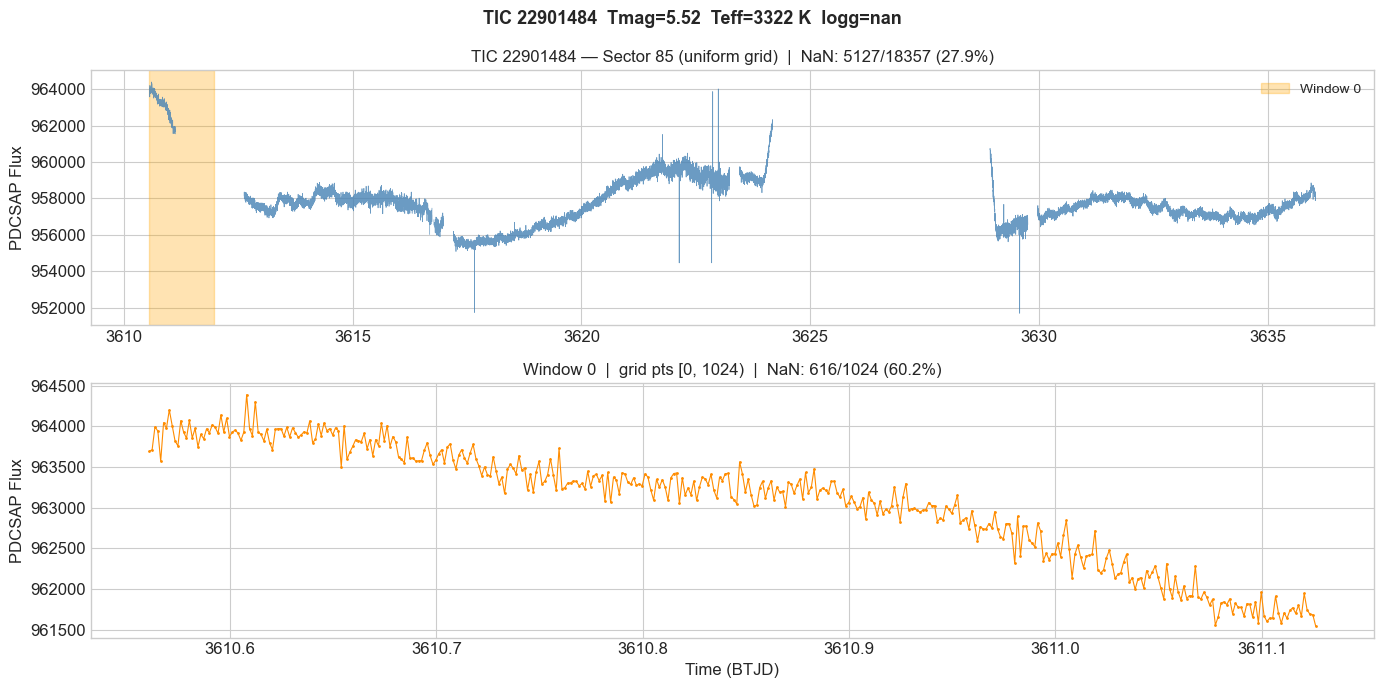

In [5]:
# Example: inspect star 0, sector 0, window 0
plot_window(2000, sector_idx=12, window_idx=0)

## Section 3 — TESS 2-min SPOC availability check

Queries MAST for every TIC ID in `df_work` to confirm SPOC 2-min cadence data exists.

Checkpoint: `processed/sector_check_results.csv` (cols: `TIC_ID, n_sectors, sector_list, status`).  
`status ∈ {done, error}` — rerun the cell to resume; `done` rows are skipped, `error` rows are retried.

In [6]:
import threading
import time
import requests
from astroquery.mast import Observations

# ── Constants ──────────────────────────────────────────────────────────────
SECTOR_CHECK_PATH  = PROCESSED / 'sector_check_results.csv'
QUERY_TIMEOUT      = 20    # astroquery socket-level cap (seconds)
THREAD_TIMEOUT     = 25    # belt-and-suspenders thread cap (seconds)
QUERY_DELAY        = 0.5   # politeness sleep between queries (seconds)
CHECKPOINT_EVERY   = 50    # flush CSV every N stars
PROGRESS_EVERY     = 50    # print progress every N stars
MAX_CONSEC_ERRORS  = 500    # abort after this many consecutive errors

Observations.TIMEOUT = QUERY_TIMEOUT

SECTOR_CHECK_COLS = ['TIC_ID', 'n_sectors', 'sector_list', 'status']


# ── Helpers ─────────────────────────────────────────────────────────────────

def _reset_mast_session() -> None:
    """Drop astroquery's HTTP session so dangling connections are closed."""
    try:
        sess = getattr(Observations, '_session', None)
        if sess is not None:
            sess.close()
    except Exception:
        pass
    try:
        Observations._session = requests.Session()
    except Exception:
        pass


def _search_one(tic_id: int) -> tuple[int, list[int], str]:
    """Call lk.search_lightcurve with a thread-level timeout.

    Returns (n_sectors, sector_list, status) where status ∈ {done, error}.
    """
    result: list = [0, [], None]

    def _run() -> None:
        try:
            sr = lk.search_lightcurve(
                f'TIC {tic_id}', mission='TESS', author='SPOC', exptime=120
            )
            n = len(sr)
            try:
                sectors = list(sr.table['sequence_number']) if n > 0 else []
            except Exception:
                sectors = []
            result[0], result[1] = n, sectors
        except Exception as exc:
            result[2] = exc

    t = threading.Thread(target=_run, daemon=True)
    t.start()
    t.join(THREAD_TIMEOUT)

    if t.is_alive():
        _reset_mast_session()
        return 0, [], 'error'
    if result[2] is not None:
        exc = result[2]
        name = type(exc).__name__
        if 'Timeout' in name or 'Connection' in name:
            _reset_mast_session()
        return 0, [], 'error'
    return result[0], result[1], 'done'


def _load_checkpoint(path) -> tuple[list[dict], set[int], set[int]]:
    """Load checkpoint CSV; return (records, done_ids, error_ids)."""
    if not Path(path).exists():
        return [], set(), set()
    df = pd.read_csv(path)
    for col in SECTOR_CHECK_COLS:
        if col not in df.columns:
            df[col] = ''
    records   = df[SECTOR_CHECK_COLS].to_dict('records')
    done_ids  = set(df.loc[df['status'] == 'done',  'TIC_ID'].astype(int))
    error_ids = set(df.loc[df['status'] == 'error', 'TIC_ID'].astype(int))
    return records, done_ids, error_ids


def _flush(records: list[dict], path) -> None:
    pd.DataFrame(records, columns=SECTOR_CHECK_COLS).to_csv(path, index=False)


def run_sector_check(tic_ids: list[int], checkpoint_path) -> pd.DataFrame:
    """Run MAST sector check for all tic_ids with checkpoint/resume.

    Returns the full sector_check DataFrame on completion.
    """
    records, done_ids, error_ids = _load_checkpoint(checkpoint_path)
    rec_index = {int(r['TIC_ID']): i for i, r in enumerate(records)}

    # Skip done; retry errors; process unseen
    skip     = done_ids
    todo     = [t for t in tic_ids if t not in skip]
    # Errors go first so a fresh run quickly confirms the outage is resolved
    todo     = [t for t in todo if t in error_ids] + [t for t in todo if t not in error_ids]

    n_total      = len(tic_ids)
    n_already    = len(done_ids)
    print(f'Total stars: {n_total:,}  |  already done: {n_already:,}  |  to process: {len(todo):,}')
    if not todo:
        print('All stars already checked.')
        return pd.DataFrame(records, columns=SECTOR_CHECK_COLS)

    t0           = time.time()
    consec_err   = 0
    aborted      = False

    try:
        for i, tic_id in enumerate(todo, start=1):
            n_sec, sec_list, status = _search_one(tic_id)

            rec = {
                'TIC_ID':      tic_id,
                'n_sectors':   n_sec,
                'sector_list': ','.join(str(s) for s in sec_list),
                'status':      status,
            }
            if tic_id in rec_index:
                records[rec_index[tic_id]] = rec
            else:
                rec_index[tic_id] = len(records)
                records.append(rec)

            if status == 'done':
                consec_err = 0
            else:
                consec_err += 1

            if i % CHECKPOINT_EVERY == 0 or i == len(todo):
                _flush(records, checkpoint_path)

            if i % PROGRESS_EVERY == 0 or status == 'error' or i == len(todo):
                elapsed  = time.time() - t0
                rate     = i / elapsed if elapsed > 0 else 0
                eta_min  = (len(todo) - i) / rate / 60 if rate > 0 else float('inf')
                n_done   = sum(1 for r in records if r['status'] == 'done')
                n_err    = sum(1 for r in records if r['status'] == 'error')
                n_data   = sum(1 for r in records if r['status'] == 'done' and int(r['n_sectors']) > 0)
                tag      = '  [error]' if status == 'error' else ''
                print(f'  [{n_already + i:>6}/{n_total}]  done={n_done:,}  w/data={n_data:,}  '
                      f'err={n_err:,}  rate={rate:.2f}/s  ETA={eta_min:.1f}min{tag}', flush=True)

            if MAX_CONSEC_ERRORS > 0 and consec_err >= MAX_CONSEC_ERRORS:
                print(f'\n⚠ {consec_err} consecutive errors — MAST may be down. '
                      f'Flushing checkpoint and aborting.\n'
                      f'  Rerun this cell to resume (error rows will be retried first).')
                aborted = True
                break

            time.sleep(QUERY_DELAY)

    except KeyboardInterrupt:
        print('\nInterrupted — flushing checkpoint.')
        aborted = True
    finally:
        _flush(records, checkpoint_path)

    if not aborted:
        n_done = sum(1 for r in records if r['status'] == 'done')
        n_err  = sum(1 for r in records if r['status'] == 'error')
        print(f'\nDone. {n_done:,} checked, {n_err:,} errors. Checkpoint: {checkpoint_path}')

    return pd.DataFrame(records, columns=SECTOR_CHECK_COLS)

In [7]:
df_sectors = run_sector_check(
    tic_ids         = df_work['ID'].astype(int).tolist(),
    checkpoint_path = SECTOR_CHECK_PATH,
)

Total stars: 594,649  |  already done: 41,221  |  to process: 553,428


No data found for target "TIC 238300964".
No data found for target "TIC 346558564".
No data found for target "TIC 365904203".
No data found for target "TIC 378647232".
No data found for target "TIC 378529587".
No data found for target "TIC 378538662".
No data found for target "TIC 432482068".
No data found for target "TIC 201502383".
No data found for target "TIC 432552443".
No data found for target "TIC 238418244".
No data found for target "TIC 257525265".
No data found for target "TIC 257468196".
No data found for target "TIC 405611514".
No data found for target "TIC 439934576".
No data found for target "TIC 259256090".
No data found for target "TIC 346930285".
No data found for target "TIC 347008505".
No data found for target "TIC 354530687".
No data found for target "TIC 372131234".
No data found for target "TIC 427317838".
No data found for target "TIC 58721030".
No data found for target "TIC 257468647".
No data found for target "TIC 347007121".
No data found for target "TIC 37305

  [ 41271/594649]  done=41,271  w/data=34,367  err=0  rate=0.38/s  ETA=24424.7min


No data found for target "TIC 201435255".
No data found for target "TIC 395316569".
No data found for target "TIC 396233032".
No data found for target "TIC 408504082".
No data found for target "TIC 373126189".
No data found for target "TIC 201632912".
No data found for target "TIC 283861491".
No data found for target "TIC 347017907".
No data found for target "TIC 201523527".
No data found for target "TIC 357331401".
No data found for target "TIC 201804105".
No data found for target "TIC 357367194".
No data found for target "TIC 429033097".
No data found for target "TIC 83054714".
No data found for target "TIC 293258348".
No data found for target "TIC 359256086".
No data found for target "TIC 407052883".
No data found for target "TIC 470919562".
No data found for target "TIC 293257148".
No data found for target "TIC 437732499".
No data found for target "TIC 201895668".
No data found for target "TIC 452892632".
No data found for target "TIC 150908130".
No data found for target "TIC 19446

  [ 41321/594649]  done=41,321  w/data=34,392  err=0  rate=0.39/s  ETA=23774.3min


...

  [ 45271/594649]  done=45,228  w/data=36,060  err=43  rate=0.25/s  ETA=37050.6min


No data found for target "TIC 702127800".
No data found for target "TIC 281920975".
No data found for target "TIC 716743599".
No data found for target "TIC 45114612".
No data found for target "TIC 232254192".
No data found for target "TIC 229238082".
No data found for target "TIC 367400116".
No data found for target "TIC 115899090".
No data found for target "TIC 127190268".
No data found for target "TIC 311223968".
No data found for target "TIC 445799874".
No data found for target "TIC 470651081".
No data found for target "TIC 116673261".
No data found for target "TIC 199960889".
No data found for target "TIC 140566523".
No data found for target "TIC 353648881".
No data found for target "TIC 247828625".
No data found for target "TIC 306239207".
No data found for target "TIC 139544562".
No data found for target "TIC 354073949".
No data found for target "TIC 389250818".
No data found for target "TIC 20308990".
No data found for target "TIC 20402382".
No data found for target "TIC 3109755

  [ 45321/594649]  done=45,278  w/data=36,078  err=43  rate=0.25/s  ETA=37015.8min


No data found for target "TIC 247552430".
No data found for target "TIC 312479567".
No data found for target "TIC 114518059".
No data found for target "TIC 89018304".
No data found for target "TIC 309116616".



Interrupted — flushing checkpoint.


## Section 4 — Filter analysis & df_final update

Merge sector-check results into `df_work`, report coverage by Tmag bin, then narrow `df_final` to stars with `n_sectors >= 1`.

In [8]:
# ── Merge sector info into df_work ──────────────────────────────────────────
df_sectors_done = df_sectors[df_sectors['status'] == 'done'].copy()
df_sectors_done['n_sectors'] = pd.to_numeric(df_sectors_done['n_sectors'], errors='coerce').fillna(0).astype(int)

df_merged = df_work.merge(
    df_sectors_done[['TIC_ID', 'n_sectors']],
    left_on='ID', right_on='TIC_ID', how='left',
)
df_merged['n_sectors'] = df_merged['n_sectors'].fillna(-1).astype(int)  # -1 = not yet checked

n_checked  = (df_merged['n_sectors'] >= 0).sum()
n_with_data = (df_merged['n_sectors'] >= 1).sum()
n_no_data   = (df_merged['n_sectors'] == 0).sum()
n_unchecked = (df_merged['n_sectors'] == -1).sum()

print(f'Total stars:      {len(df_merged):,}')
print(f'Checked:          {n_checked:,}')
print(f'  w/ SPOC data:   {n_with_data:,}  ({100*n_with_data/max(n_checked,1):.1f}% of checked)')
print(f'  no SPOC data:   {n_no_data:,}')
print(f'Not yet checked:  {n_unchecked:,}')

# ── Coverage by Tmag bin ─────────────────────────────────────────────────────
bins   = [(None, 7, 'Tmag < 7'), (7, 8, 'Tmag 7-8'), (8, 9, 'Tmag 8-9'), (9, 10, 'Tmag 9-10')]
print(f'\n{"Tmag bin":<14} {"Stars":>8} {"Checked":>9} {"w/data":>9} {"Coverage":>10}')
print('-' * 54)
for lo, hi, label in bins:
    mask = (df_merged['Tmag'] >= (lo if lo is not None else -99)) & (df_merged['Tmag'] < hi)
    sub  = df_merged[mask]
    chk  = (sub['n_sectors'] >= 0).sum()
    wdt  = (sub['n_sectors'] >= 1).sum()
    cov  = f'{100*wdt/max(chk,1):.1f}%' if chk > 0 else 'N/A'
    print(f'{label:<14} {len(sub):>8,} {chk:>9,} {wdt:>9,} {cov:>10}')

# ── Update df_final: only stars with confirmed SPOC data ────────────────────
df_final = df_merged[df_merged['n_sectors'] >= 1][['ID']].copy().reset_index(drop=True)
print(f'\ndf_final updated: {len(df_final):,} stars (n_sectors >= 1)')
if n_unchecked > 0:
    print(f'  [Note] {n_unchecked:,} stars not yet checked — rerun Section 3 to completion for final counts.')

Total stars:      41,221
Checked:          41,221
  w/ SPOC data:   34,343  (83.3% of checked)
  no SPOC data:   6,878
Not yet checked:  0

Tmag bin          Stars   Checked    w/data   Coverage
------------------------------------------------------
Tmag < 7          7,113     7,113     6,654      93.5%
Tmag 7-8          7,747     7,747     6,978      90.1%
Tmag 8-9         11,548    11,548     9,534      82.6%
Tmag 9-10        14,813    14,813    11,177      75.5%

df_final updated: 34,343 stars (n_sectors >= 1)


## Section 5 — Sanity check: dwarf vs evolved star contamination

Gaia BP/RP are absent from the batch CSVs, so `logg` is used as the discriminant.
Note: `logg` null rate is ~57% — classification applies only to stars with available `logg`.

Category               Tmag < 7          Tmag 7-10
--------------------------------------------------
dwarf             3,340 (47.0%)     29,643 (86.9%)
subgiant          1,595 (22.4%)         690 (2.0%)
giant                  0 (0.0%)           0 (0.0%)
unknown           2,178 (30.6%)      3,775 (11.1%)
Total                     7,113             34,108

logg null rate: Tmag<7=30.6%  Tmag7-10=11.1%
  (Classification above is only over stars with logg available)


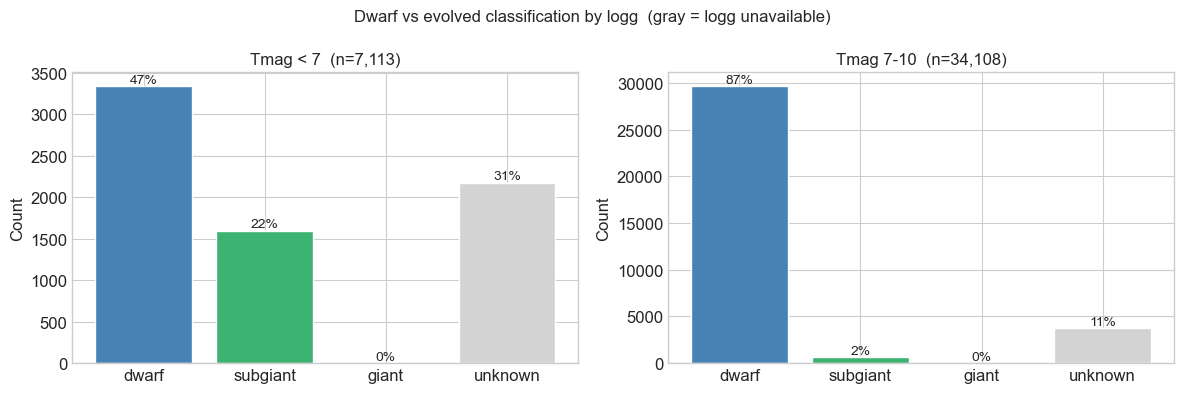

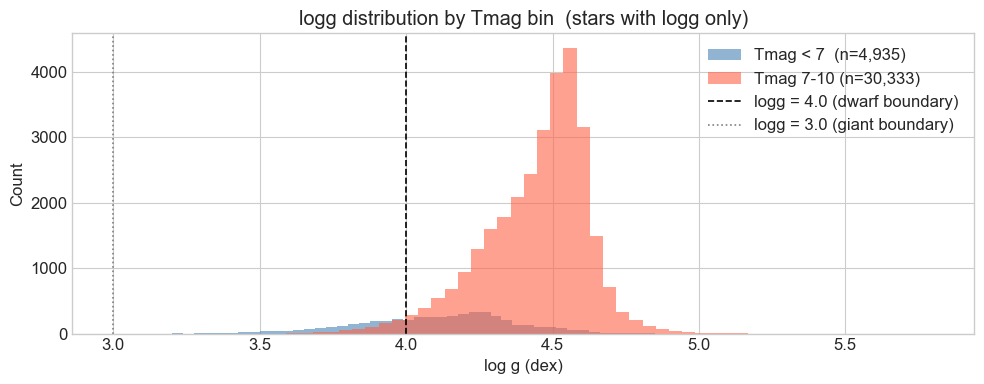

In [9]:
def classify_logg(df: pd.DataFrame) -> pd.Series:
    """Classify stars by logg into dwarf / subgiant / giant / unknown."""
    out = pd.Series('unknown', index=df.index)
    has = df['logg'].notna()
    out[has & (df['logg'] >= 4.0)]                       = 'dwarf'
    out[has & (df['logg'] >= 3.0) & (df['logg'] < 4.0)] = 'subgiant'
    out[has & (df['logg'] < 3.0)]                        = 'giant'
    return out

old = df_work[df_work['Tmag'] < 7].copy()
new = df_work[df_work['Tmag'] >= 7].copy()
old['class'] = classify_logg(old)
new['class'] = classify_logg(new)

cats   = ['dwarf', 'subgiant', 'giant', 'unknown']
colors = ['steelblue', 'mediumseagreen', 'tomato', 'lightgray']

def pct_str(df: pd.DataFrame, cat: str) -> str:
    n   = (df['class'] == cat).sum()
    pct = 100 * n / len(df) if len(df) > 0 else 0
    return f'{n:,} ({pct:.1f}%)'

header = f"{'Category':<12} {'Tmag < 7':>18} {'Tmag 7-10':>18}"
print(header)
print('-' * 50)
for cat in cats:
    print(f'{cat:<12} {pct_str(old, cat):>18} {pct_str(new, cat):>18}')
print(f'{"Total":<12} {len(old):>18,} {len(new):>18,}')
logg_null_old = old['logg'].isna().mean()
logg_null_new = new['logg'].isna().mean()
print(f'\nlogg null rate: Tmag<7={logg_null_old:.1%}  Tmag7-10={logg_null_new:.1%}')
print('  (Classification above is only over stars with logg available)')

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, df_sub, title in zip(axes, [old, new], ['Tmag < 7', 'Tmag 7-10']):
    counts = [(df_sub['class'] == c).sum() for c in cats]
    bars   = ax.bar(cats, counts, color=colors, edgecolor='white')
    ax.set_title(f'{title}  (n={len(df_sub):,})', fontsize=12)
    ax.set_ylabel('Count')
    for bar, cnt in zip(bars, counts):
        pct = 100 * cnt / len(df_sub) if len(df_sub) else 0
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=10)

fig.suptitle('Dwarf vs evolved classification by logg  (gray = logg unavailable)', fontsize=12)
plt.tight_layout()
plt.show()

# logg histogram overlay
fig, ax = plt.subplots(figsize=(10, 4))
old_logg = old['logg'].dropna()
new_logg = new['logg'].dropna()
ax.hist(old_logg, bins=50, alpha=0.6, color='steelblue', label=f'Tmag < 7  (n={len(old_logg):,})')
ax.hist(new_logg, bins=50, alpha=0.6, color='tomato',    label=f'Tmag 7-10 (n={len(new_logg):,})')
ax.axvline(4.0, color='black', lw=1.2, linestyle='--', label='logg = 4.0 (dwarf boundary)')
ax.axvline(3.0, color='gray',  lw=1.2, linestyle=':',  label='logg = 3.0 (giant boundary)')
ax.set_xlabel('log g (dex)')
ax.set_ylabel('Count')
ax.set_title('logg distribution by Tmag bin  (stars with logg only)')
ax.legend()
plt.tight_layout()
plt.show()

## Section 6 — Export & summary

In [ ]:
out_path = PROCESSED / 'df_final.csv'
df_final[['ID']].to_csv(out_path, index=False)
print(f'Exported {len(df_final):,} TIC IDs to {out_path}')
print(f'Columns: {list(df_final.columns)}')

df_work_tmag = df_final.merge(df_work[['ID', 'Tmag']], on='ID', how='left')

print('\n========== Cut funnel summary ==========')
print(f'  Raw combined batches:    {len(df_raw):>8,}')
print(f'  After Tmag < 10:         {len(df_work):>8,}')
print(f'  After n_sectors >= 1:    {len(df_final):>8,}  <- df_final')
print(f'    of which Tmag < 7:     {(df_work_tmag["Tmag"] < 7).sum():>8,}')
print(f'    of which Tmag 7-10:    {(df_work_tmag["Tmag"] >= 7).sum():>8,}')
print()
print('Stellar class (stars with logg, pre-SPOC-filter):')
for cat in cats:
    print(f'  {cat:<10} old={pct_str(old, cat):>18}  new={pct_str(new, cat):>18}')